In [34]:
# Parte 0: Preparación de datos (necesaria para los gráficos siguientes)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid")

df = pd.read_csv('https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/netflix_titles.csv')

# Fechas -> year_added / month_added
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Duración en minutos (solo aplica a Movies)
df['duration_minutes'] = df['duration'].str.extract(r'(\d+)\s*min').astype(float)

# Género explotado (una fila por género)
df_generos = df.assign(genre=df['listed_in'].str.split(',')).explode('genre')
df_generos['genre'] = df_generos['genre'].str.strip()

print("df listo:", df.shape, "| df_generos listo:", df_generos.shape)
df.head()

df listo: (8807, 15) | df_generos listo: (19323, 16)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_minutes
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,90.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,NaN


/tmp/ipykernel_975/1166915491.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', order=df['type'].value_counts().index, palette='viridis')


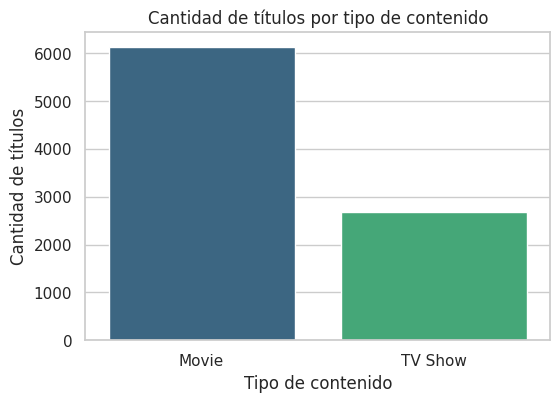

In [35]:
# Parte 1.1: Distribución de tipos de contenido (Movie vs TV Show)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', order=df['type'].value_counts().index, palette='viridis')
plt.title('Cantidad de títulos por tipo de contenido')
plt.xlabel('Tipo de contenido')
plt.ylabel('Cantidad de títulos')
plt.show()

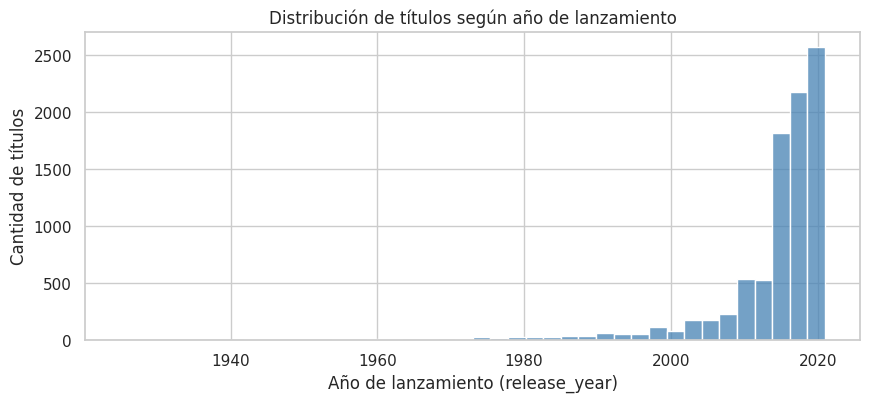

In [36]:
# Parte 1.2: Histograma de años de lanzamiento (release_year)
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='release_year', bins=40, color='steelblue')
plt.title('Distribución de títulos según año de lanzamiento')
plt.xlabel('Año de lanzamiento (release_year)')
plt.ylabel('Cantidad de títulos')
plt.show()

/tmp/ipykernel_975/2111052548.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='rating', order=orden_rating, palette='mako')


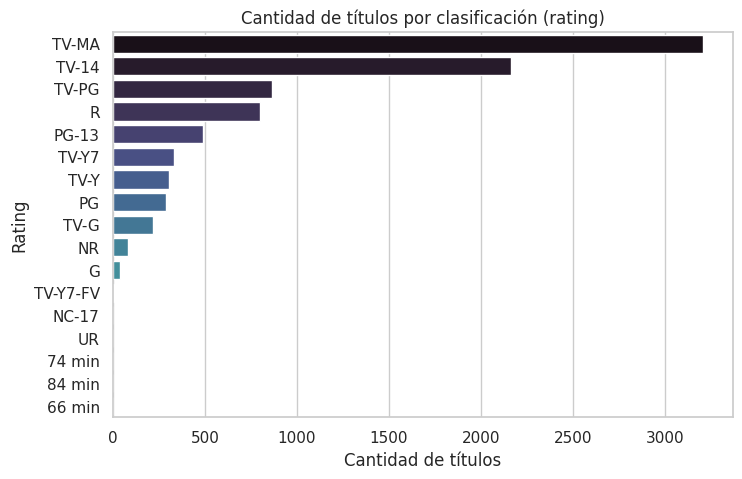

In [37]:
# Parte 1.3: Proporción de clasificaciones por edad (rating)
plt.figure(figsize=(8, 5))
orden_rating = df['rating'].value_counts().index
sns.countplot(data=df, y='rating', order=orden_rating, palette='mako')
plt.title('Cantidad de títulos por clasificación (rating)')
plt.xlabel('Cantidad de títulos')
plt.ylabel('Rating')
plt.show()

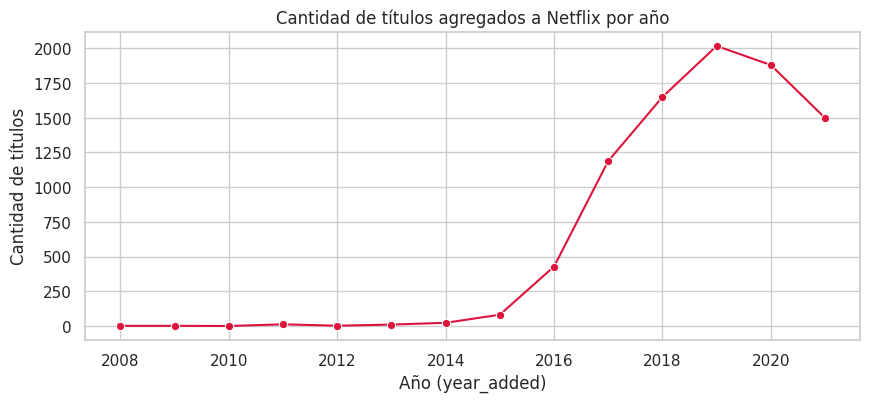

In [38]:
# Parte 2.1: Número de títulos agregados por año (serie temporal)
titulos_por_anio = df['year_added'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
sns.lineplot(x=titulos_por_anio.index, y=titulos_por_anio.values, marker='o', color='crimson')
plt.title('Cantidad de títulos agregados a Netflix por año')
plt.xlabel('Año (year_added)')
plt.ylabel('Cantidad de títulos')
plt.show()

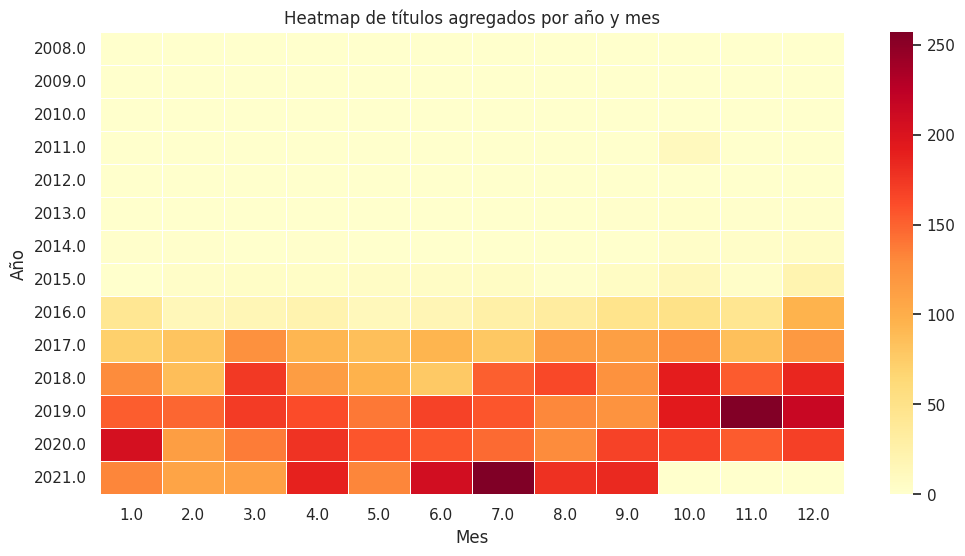

In [39]:
# Parte 2.2: Heatmap de lanzamientos por año y mes
tabla_year_month = pd.pivot_table(
    df, index='year_added', columns='month_added',
    values='show_id', aggfunc='count', fill_value=0
)

plt.figure(figsize=(12, 6))
sns.heatmap(tabla_year_month, cmap='YlOrRd', annot=False, linewidths=0.5)
plt.title('Heatmap de títulos agregados por año y mes')
plt.xlabel('Mes')
plt.ylabel('Año')
plt.show()

/tmp/ipykernel_975/3488792310.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=peliculas_top_generos, x='duration_minutes', y='genre', palette='coolwarm')


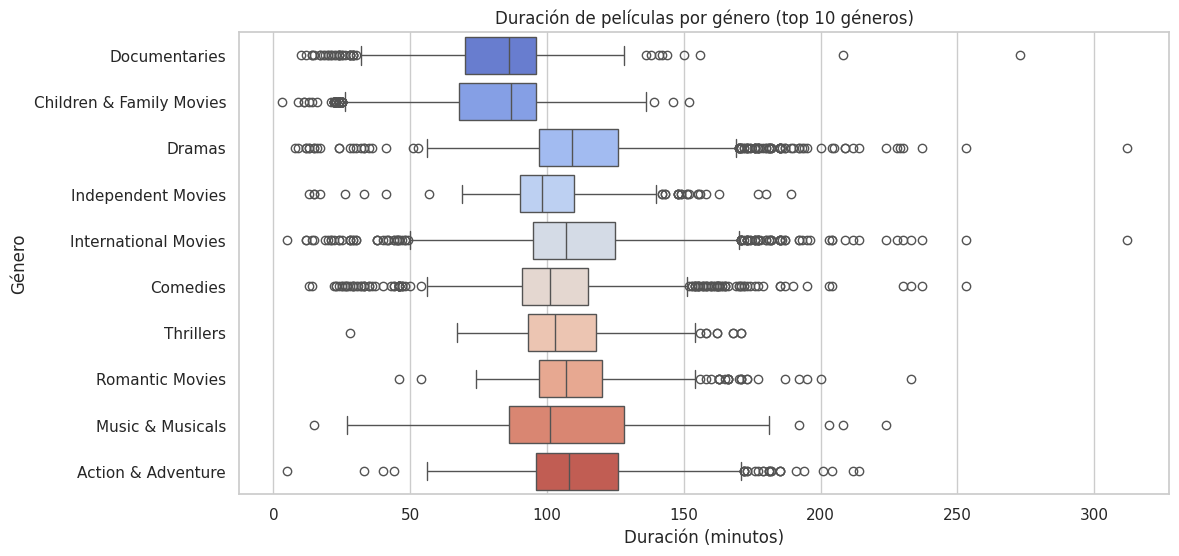

In [40]:
# Parte 2.3: Duración de películas por género (boxplot)
peliculas_genero = df_generos.loc[df_generos['type'] == 'Movie']

# Nos quedamos con los 10 géneros más frecuentes para que el gráfico no se sature
top10_generos = peliculas_genero['genre'].value_counts().head(10).index
peliculas_top_generos = peliculas_genero.loc[peliculas_genero['genre'].isin(top10_generos)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=peliculas_top_generos, x='duration_minutes', y='genre', palette='coolwarm')
plt.title('Duración de películas por género (top 10 géneros)')
plt.xlabel('Duración (minutos)')
plt.ylabel('Género')
plt.show()

/tmp/ipykernel_975/288338360.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_paises.values, y=top10_paises.index, palette='crest')


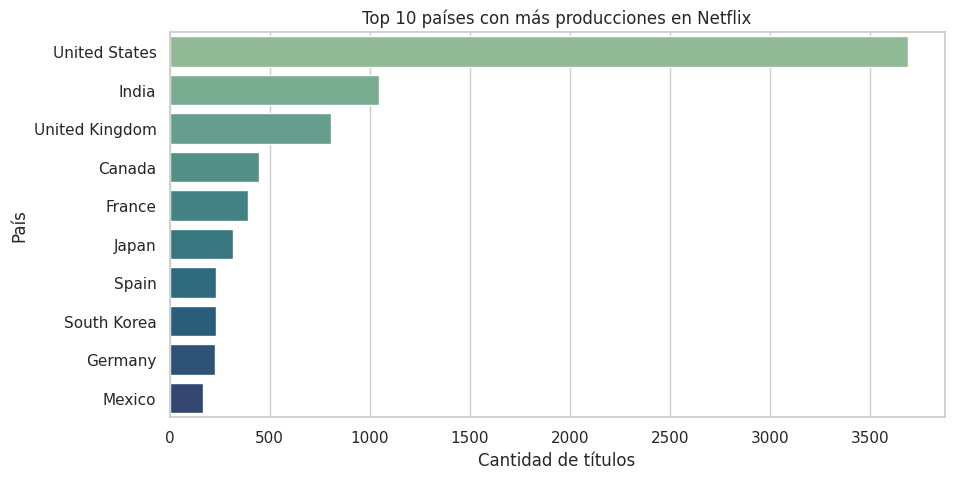

In [41]:
# Parte 3.1: Top 10 países con más producciones
paises_explotados = df.assign(country=df['country'].str.split(',')).explode('country')
paises_explotados['country'] = paises_explotados['country'].str.strip()

top10_paises = paises_explotados['country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top10_paises.values, y=top10_paises.index, palette='crest')
plt.title('Top 10 países con más producciones en Netflix')
plt.xlabel('Cantidad de títulos')
plt.ylabel('País')
plt.show()

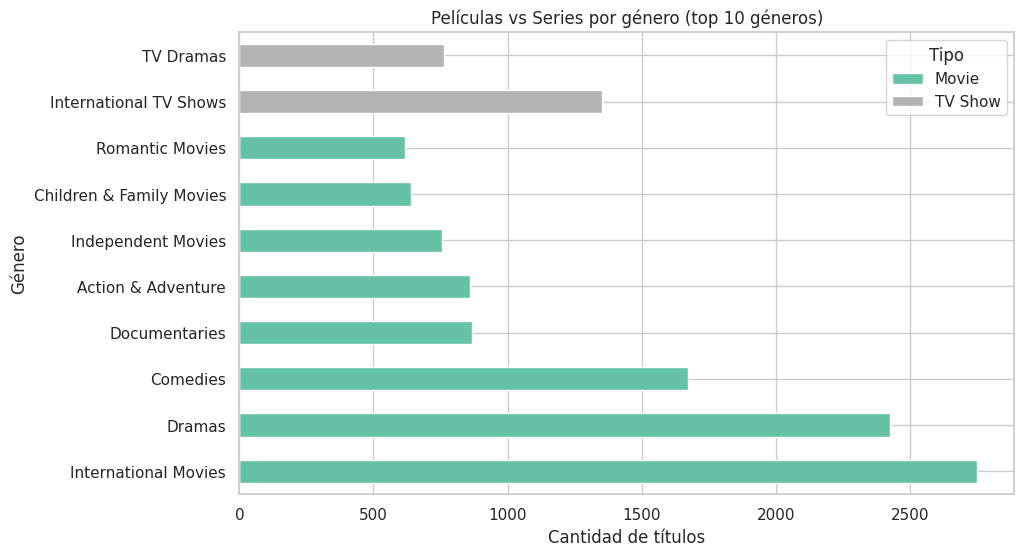

In [42]:
# Parte 3.2: Películas vs Series según género (barras apiladas)
top10_generos_general = df_generos['genre'].value_counts().head(10).index
df_top_generos = df_generos.loc[df_generos['genre'].isin(top10_generos_general)]

tabla_tipo_genero = pd.pivot_table(
    df_top_generos, index='genre', columns='type',
    values='show_id', aggfunc='count', fill_value=0
).sort_values(by='Movie', ascending=False)

tabla_tipo_genero.plot(kind='barh', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Películas vs Series por género (top 10 géneros)')
plt.xlabel('Cantidad de títulos')
plt.ylabel('Género')
plt.legend(title='Tipo')
plt.show()

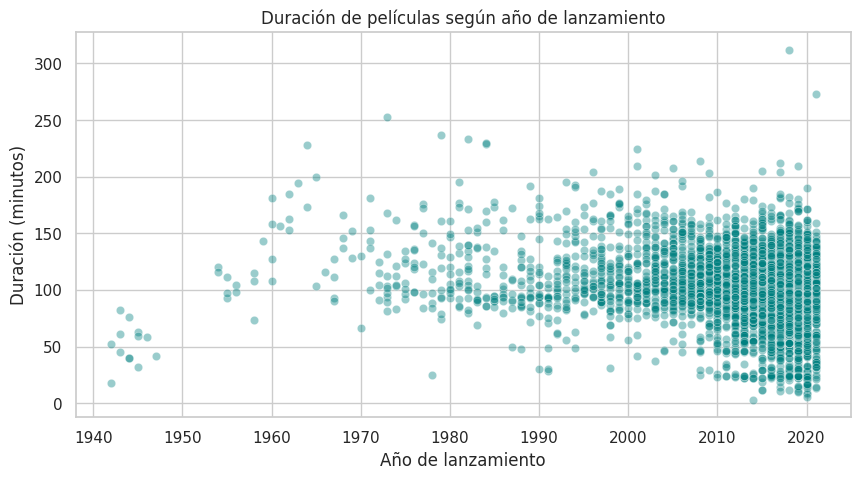

In [43]:
# Parte 3.3: Relación entre duración y año de lanzamiento (scatterplot)
peliculas = df.loc[df['type'] == 'Movie']

plt.figure(figsize=(10, 5))
sns.scatterplot(data=peliculas, x='release_year', y='duration_minutes', alpha=0.4, color='teal')
plt.title('Duración de películas según año de lanzamiento')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Duración (minutos)')
plt.show()

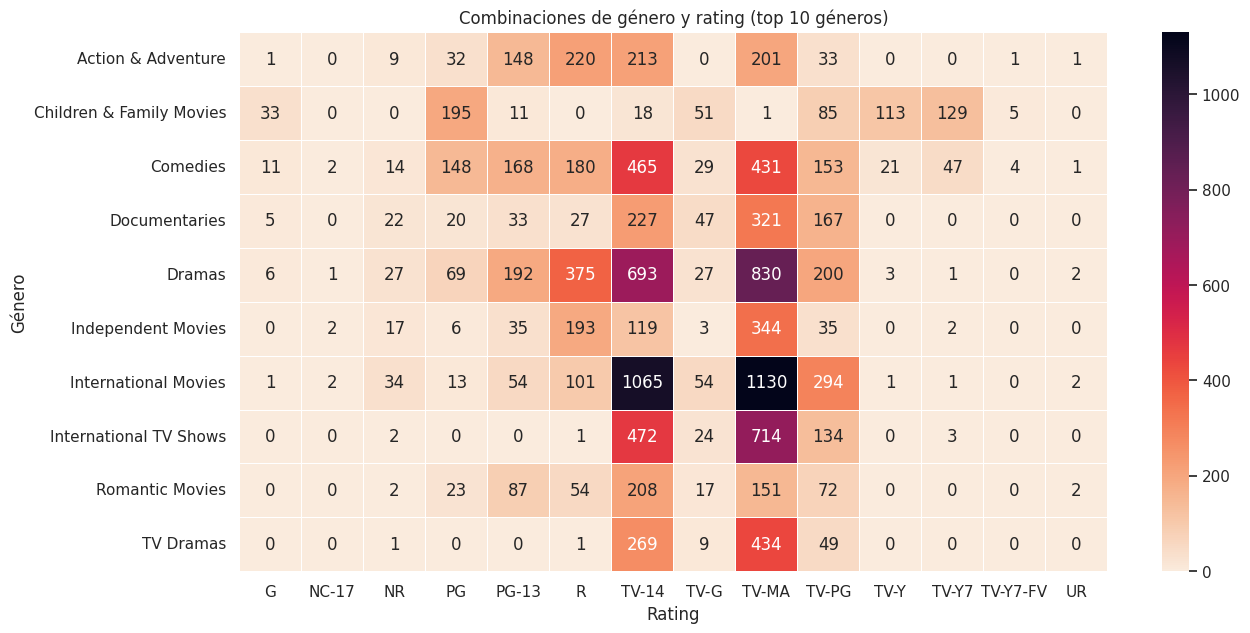

In [44]:
# Desafío Final: heatmap de combinaciones género + rating
top10_generos_final = df_generos['genre'].value_counts().head(10).index
df_desafio = df_generos.loc[df_generos['genre'].isin(top10_generos_final)]

tabla_genero_rating = pd.pivot_table(
    df_desafio, index='genre', columns='rating',
    values='show_id', aggfunc='count', fill_value=0
)

plt.figure(figsize=(14, 7))
sns.heatmap(tabla_genero_rating, cmap='rocket_r', annot=True, fmt='.0f', linewidths=0.5)
plt.title('Combinaciones de género y rating (top 10 géneros)')
plt.xlabel('Rating')
plt.ylabel('Género')
plt.show()